In [1]:
#imports 
import pyfar as pf 
import matplotlib as mpl
import matplotlib.pyplot as plt 
#from playaudio import playaudio
import numpy as np
import sounddevice as sd
import scipy 

# Three versions of HRTF

- raw 
- windowed room for onset 
- freefield for equalization 
- freefield_minphase to eliminate artifacts such as pre-ringing
- no ITD (HRTF interpolation and compatibility with TUNE-In Toolkit)

In [2]:
#path 
raw = 'dataset/dataset/P0001/HRTF/HRTF/48kHz/P0001_Raw_48kHz.sofa'
raw_noITD = 'dataset/dataset/P0001/HRTF/HRTF/48kHz/P0001_Raw_NoITD_48kHz.sofa'

windowed = 'dataset/dataset/P0001/HRTF/HRTF/48kHz/P0001_Windowed_48kHz.sofa'
windowed_noITD = 'dataset/dataset/P0001/HRTF/HRTF/48kHz/P0001_Windowed_NoITD_48kHz.sofa'

freefield = 'dataset/dataset/P0001/HRTF/HRTF/48kHz/P0001_FreeFieldComp_48kHz.sofa'
freefield_noITD = 'dataset/dataset/P0001/HRTF/HRTF/48kHz/P0001_FreeFieldComp_NoITD_48kHz.sofa'

freefield_minphase = 'dataset/dataset/P0001/HRTF/HRTF/48kHz/P0001_FreeFieldCompMinPhase_48kHz.sofa'
freefield_minphase_noITD = 'dataset/dataset/P0001/HRTF/HRTF/48kHz/P0001_FreeFieldCompMinPhase_NoITD_48kHz.sofa'



In [3]:
# Hrtf visualisation
data_raw, source_coordinates1, receiver_coordinates1 = pf.io.read_sofa(raw)
data_raw_noITD, source_coordinates2, receiver_coordinates2 = pf.io.read_sofa(raw_noITD)

data_windowed, source_coordinates3, receiver_coordinates3 = pf.io.read_sofa(windowed)
data_windowed_noITD, source_coordinates4, receiver_coordinates4 = pf.io.read_sofa(windowed_noITD)

data_freefield, source_coordinates5, receiver_coordinates5 = pf.io.read_sofa(freefield)
data_freefield_noITD, source_coordinates6, receiver_coordinates6 = pf.io.read_sofa(freefield_noITD)

data_freefield_minphase, source_coordinates7, receiver_coordinates7 = pf.io.read_sofa(freefield_minphase)
data_freefield_minphase_noITD, source_coordinates8, receiver_coordinates8 = pf.io.read_sofa(freefield_minphase_noITD)

SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription

## Comparison with position 
### azimuth

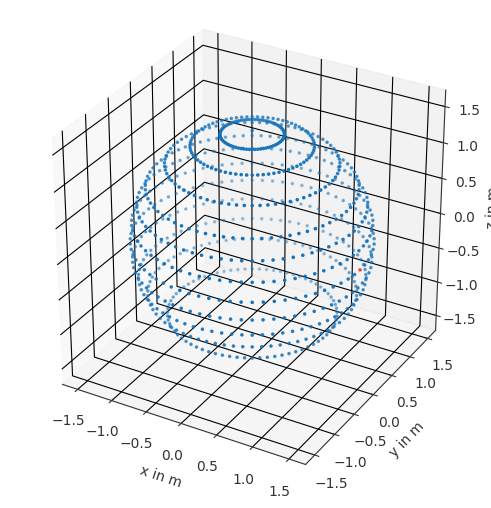

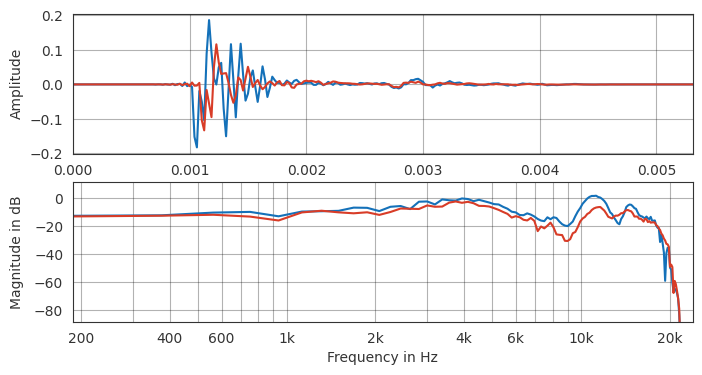

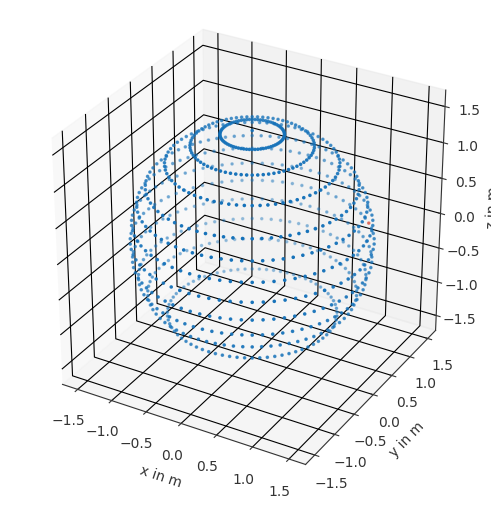

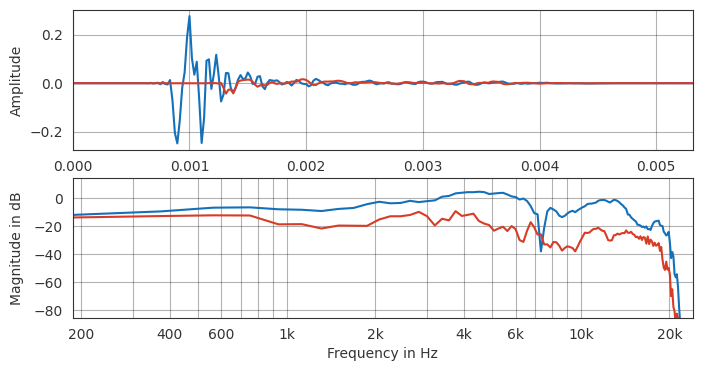

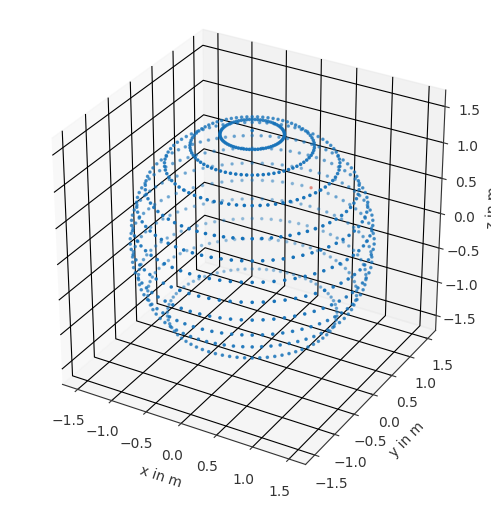

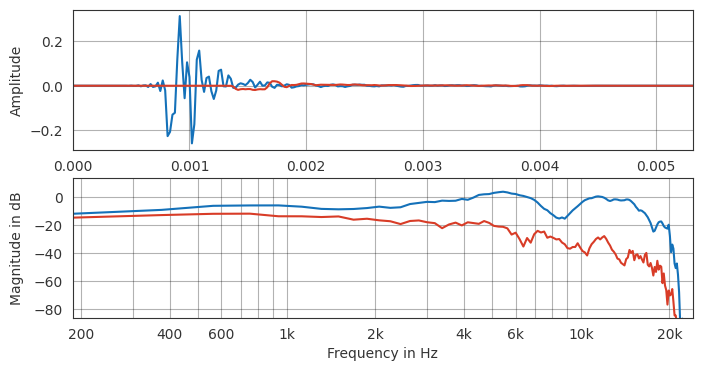

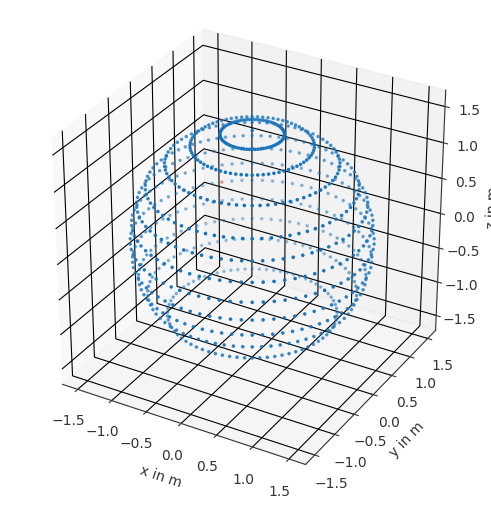

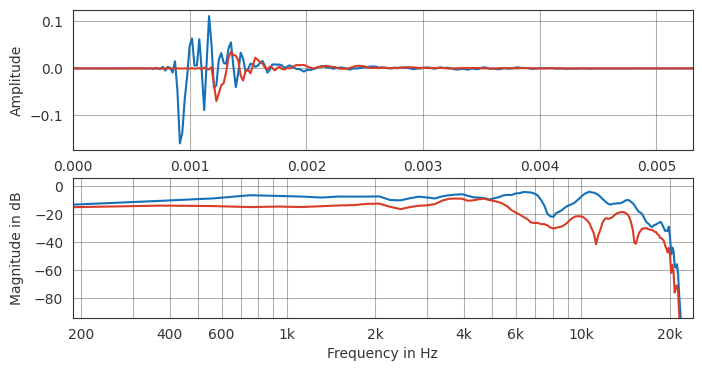

In [4]:
angles = [0, np.pi/4, np.pi/2, np.pi*3/4 ]
indexes = []

for ang in angles:
    target_point = pf.Coordinates.from_spherical_elevation(ang, 0, 1.5)
    index, *_ = source_coordinates5.find_nearest(target_point,k=1)
    indexes.append(index)

for ind in indexes: 
    source_coordinates5.show(ind)
    fig = plt.figure(figsize=(8,4))
    pf.plot.time_freq(data_freefield_minphase[ind])




### Elevation

In [5]:
angles = [np.pi*5/3, 0, np.pi/3]
indexes = []

for ang in angles:
    target_point = pf.Coordinates.from_spherical_elevation(0, ang, 1.5)
    index, *_ = source_coordinates5.find_nearest(target_point,k=1)
    indexes.append(index)

for ind in indexes: 
    source_coordinates5.show(ind)
    fig = plt.figure(figsize=(8,4))
    pf.plot.time_freq(data_freefield_minphase[ind])

# Simulation de la spatialisation

In [12]:
# audio imports for simulation
audio='dataset/dataset/audio/wassim perc.wav'
sinewave = 'dataset/dataset/audio/sinewave.wav'

In [13]:
# play audio
ang = np.pi/6

target_point = pf.Coordinates.from_spherical_elevation(ang, 0, 1.5)
index, *_ = source_coordinates5.find_nearest(target_point,k=1)

sd.play(data_freefield_minphase[index].time.T, data_freefield_minphase.sampling_rate)

sd.wait()

In [14]:
# original audio 
sr, x= scipy.io.wavfile.read(sinewave)
x = x.astype(np.float32) / np.max(np.abs(x))
x_left = x[:,0]

sd.play(x_left, data_freefield_minphase.sampling_rate)



In [19]:
impulse_left= data_freefield_minphase.time[index[0],0]
impulse_right= data_freefield_minphase.time[index[0],1]

#load audio 
sr, x= scipy.io.wavfile.read(sinewave)
x = x.astype(np.float32) / np.max(np.abs(x))
x_mono = np.mean(x, axis=1) 

#convolution
spatial_audio_left = np.convolve(impulse_left,x_mono)
spatial_audio_right = np.convolve(impulse_right,x_mono)

spatial_audio = np.column_stack((spatial_audio_left, spatial_audio_right))


sd.play(spatial_audio, data_freefield_minphase.sampling_rate)

sd.wait()